# DeepSculpt v2.0 - Working Training Notebook

Complete workflow: Dataset Creation → Training → Generation

This notebook contains the working training pipeline converted from the debugged script.

## 1. Setup and Imports

In [1]:
import sys
import os
from pathlib import Path
import time
import json

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

# Core imports
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU")

PyTorch version: 2.2.2
CUDA available: False
Running on CPU


In [2]:
# Import DeepSculpt modules
from core.data.generation.pytorch_sculptor import PyTorchSculptor
from core.data.generation.pytorch_collector import PyTorchCollector
from core.models.model_factory import PyTorchModelFactory
from core.training.pytorch_trainer import GANTrainer, TrainingConfig
from core.visualization.pytorch_visualization import PyTorchVisualizer
from core.utils.pytorch_utils import PyTorchUtils

print("✅ All modules imported successfully")

✅ All modules imported successfully


/Users/juan-garassino/Code/003-research/001-deep-projects/004-deepSculpt/deepSculpt/deepsculpt/core/workflow/pytorch_mlflow_tracking.py:49: UserWarning: MLflow not available, experiment tracking disabled
  warnings.warn("MLflow not available, experiment tracking disabled")
/Users/juan-garassino/Code/003-research/001-deep-projects/004-deepSculpt/deepSculpt/deepsculpt/core/data/generation/pytorch_collector.py:60: UserWarning: zarr not available, Zarr format disabled
  warnings.warn("zarr not available, Zarr format disabled")


## 2. Configuration

In [3]:
# Configuration
CONFIG = {
    # Data generation
    'void_dim': 16,
    'num_samples': 10,
    'num_shapes': 3,
    
    # Model architecture
    'model_type': 'simple',
    'noise_dim': 50,
    'color_mode': 0,  # 0=monochrome, 1=color
    
    # Training
    'epochs': 2,
    'batch_size': 4,
    'learning_rate': 0.0002,
    'beta1': 0.5,
    'beta2': 0.999,
    
    # Generation
    'num_eval_samples': 3,
    
    # System
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'sparse_mode': False,
    'mixed_precision': False,
    
    # Paths
    'output_dir': './notebook_output',
}

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Configuration:
  void_dim: 16
  num_samples: 10
  num_shapes: 3
  model_type: simple
  noise_dim: 50
  color_mode: 0
  epochs: 2
  batch_size: 4
  learning_rate: 0.0002
  beta1: 0.5
  beta2: 0.999
  num_eval_samples: 3
  device: cpu
  sparse_mode: False
  mixed_precision: False
  output_dir: ./notebook_output


## 3. Dataset Class

In [4]:
class SimpleDataset(Dataset):
    """Simple dataset for loading generated samples."""
    
    def __init__(self, file_paths, device='cpu'):
        self.file_paths = file_paths
        self.device = device
    
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        # Load structure
        structure = torch.load(self.file_paths[idx])
        
        # Ensure correct shape (add channel dimension if needed)
        if structure.dim() == 3:
            structure = structure.unsqueeze(0)
        
        # Convert to float and normalize
        structure = structure.float()
        if structure.max() > 1.0:
            structure = structure / 255.0
        
        return structure.to(self.device)

print("✅ Dataset class defined")

✅ Dataset class defined


## 4. Generate Dataset

In [5]:
# Create output directory
output_dir = Path(CONFIG['output_dir'])
data_dir = output_dir / 'data'
data_dir.mkdir(parents=True, exist_ok=True)

print(f"📁 Output directory: {output_dir}")
print(f"📁 Data directory: {data_dir}")

📁 Output directory: notebook_output
📁 Data directory: notebook_output/data


In [6]:
# Configure sculptor
sculptor_config = {
    'void_dim': CONFIG['void_dim'],
    'edges': (1, 0.3, 0.5),
    'planes': (1, 0.3, 0.5),
    'pipes': (1, 0.3, 0.5),
    'grid': (1, 4),
    'step': 1,
}

# Create collector
collector = PyTorchCollector(
    sculptor_config=sculptor_config,
    output_format='pytorch',
    base_dir=str(data_dir),
    device=CONFIG['device'],
    sparse_mode=CONFIG['sparse_mode'],
    verbose=True,
)

print(f"✅ Collector created")

────────────────────────────────────────── Initializing PyTorchCollector ──────────────────────────────────────────

✓ PyTorchCollector initialized with format=pytorch, device=cpu

Completed Initializing PyTorchCollector in 0.01s

✅ Collector created


In [7]:
# Generate dataset
print(f"🎨 Generating {CONFIG['num_samples']} samples...\n")
start_time = time.time()

sample_paths = collector.create_collection(
    num_samples=CONFIG['num_samples'],
    batch_size=CONFIG['batch_size'],
    dynamic_batching=False,
)

generation_time = time.time() - start_time

print(f"\n✅ Generated {len(sample_paths)} samples in {generation_time:.2f}s")
print(f"⏱️  Average: {generation_time/len(sample_paths):.3f}s per sample")

🎨 Generating 10 samples...



──────────────────────────────────────── Creating collection of 10 samples ────────────────────────────────────────

ℹ Generating batch 0-3 (size: 4)

────────────────────────────────────────── Initializing PyTorchSculptor ───────────────────────────────────────────

ℹ Using device: cpu

...

✓ Saved collection metadata to notebook_output/data/2025-11-10/metadata/collection_metadata.json

✓ Generated 10 samples in 1.83 seconds

ℹ Average time per sample: 0.183 seconds

Completed Creating collection of 10 samples in 1.85s


✅ Generated 10 samples in 1.85s
⏱️  Average: 0.185s per sample


## 5. Create DataLoader

In [8]:
# Create dataset and dataloader
dataset = SimpleDataset(sample_paths, device=CONFIG['device'])
dataloader = DataLoader(
    dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=0,
)

print(f"✅ Created dataset with {len(dataset)} samples")
print(f"📦 Batch size: {CONFIG['batch_size']}")
print(f"🔄 Number of batches: {len(dataloader)}")

# Test batch
test_batch = next(iter(dataloader))
print(f"\n📊 Test batch shape: {test_batch.shape}")
print(f"📊 Test batch dtype: {test_batch.dtype}")

✅ Created dataset with 10 samples
📦 Batch size: 4
🔄 Number of batches: 3

📊 Test batch shape: torch.Size([4, 1, 16, 16, 16])
📊 Test batch dtype: torch.float32


## 6. Create Models

In [9]:
# Create model factory
factory = PyTorchModelFactory(device=CONFIG['device'])

# Create generator
generator = factory.create_gan_generator(
    model_type=CONFIG['model_type'],
    void_dim=CONFIG['void_dim'],
    noise_dim=CONFIG['noise_dim'],
    color_mode=CONFIG['color_mode'],
    sparse=CONFIG['sparse_mode'],
)

print("✅ Generator created")
gen_info = factory.get_model_info(generator)
print(f"  Parameters: {gen_info['total_parameters']:,}")
print(f"  Memory: {gen_info['memory_usage_mb']:.2f} MB")

✅ Generator created
  Parameters: 130,648
  Memory: 0.50 MB


In [10]:
# Create discriminator
discriminator = factory.create_gan_discriminator(
    model_type=CONFIG['model_type'],
    void_dim=CONFIG['void_dim'],
    color_mode=CONFIG['color_mode'],
    sparse=CONFIG['sparse_mode'],
)

print("✅ Discriminator created")
disc_info = factory.get_model_info(discriminator)
print(f"  Parameters: {disc_info['total_parameters']:,}")
print(f"  Memory: {disc_info['memory_usage_mb']:.2f} MB")

✅ Discriminator created
  Parameters: 11,016,577
  Memory: 42.03 MB


In [11]:
# Test generator
test_noise = torch.randn(1, CONFIG['noise_dim'], device=CONFIG['device'])
with torch.no_grad():
    test_output = generator(test_noise)

print(f"🧪 Generator test:")
print(f"  Input: {test_noise.shape}")
print(f"  Output: {test_output.shape}")
print(f"  Range: [{test_output.min():.3f}, {test_output.max():.3f}]")

🧪 Generator test:
  Input: torch.Size([1, 50])
  Output: torch.Size([1, 1, 16, 16, 16])
  Range: [1.000, 1.000]


## 7. Training Setup

In [12]:
# Create log directory
log_dir = output_dir / 'logs'
log_dir.mkdir(parents=True, exist_ok=True)

# Training configuration
training_config = TrainingConfig(
    epochs=CONFIG['epochs'],
    batch_size=CONFIG['batch_size'],
    learning_rate=CONFIG['learning_rate'],
    mixed_precision=CONFIG['mixed_precision'],
    gradient_clip=1.0,
    checkpoint_freq=1,
    log_dir=str(log_dir),
    use_tensorboard=False,
    use_wandb=False,
    use_mlflow=False,
)

print("✅ Training config created")

✅ Training config created


In [13]:
# Create optimizers
gen_optimizer = torch.optim.Adam(
    generator.parameters(),
    lr=CONFIG['learning_rate'],
    betas=(CONFIG['beta1'], CONFIG['beta2']),
)

disc_optimizer = torch.optim.Adam(
    discriminator.parameters(),
    lr=CONFIG['learning_rate'],
    betas=(CONFIG['beta1'], CONFIG['beta2']),
)

print("✅ Optimizers created")

✅ Optimizers created


In [14]:
# Create trainer
trainer = GANTrainer(
    generator=generator,
    discriminator=discriminator,
    gen_optimizer=gen_optimizer,
    disc_optimizer=disc_optimizer,
    config=training_config,
    device=CONFIG['device'],
    noise_dim=CONFIG['noise_dim'],
)

print("✅ Trainer created")

✅ Trainer created


## 8. Training

In [15]:
# Create checkpoint directory
checkpoint_dir = output_dir / 'checkpoints'
checkpoint_dir.mkdir(exist_ok=True)

print(f"🚀 Starting training for {CONFIG['epochs']} epochs...\n")
start_time = time.time()

# Initialize metrics
all_metrics = {
    'gen_loss': [],
    'disc_loss': [],
    'disc_real_acc': [],
    'disc_fake_acc': [],
}

# Training loop
for epoch in range(CONFIG['epochs']):
    print(f"Epoch {epoch+1}/{CONFIG['epochs']}")
    
    # Train for one epoch
    epoch_metrics = trainer.train_epoch(dataloader)
    
    # Store metrics
    for key in all_metrics.keys():
        if key in epoch_metrics:
            all_metrics[key].append(epoch_metrics[key])
    
    # Print summary
    print(f"  Gen Loss: {epoch_metrics.get('gen_loss', 0):.4f}")
    print(f"  Disc Loss: {epoch_metrics.get('disc_loss', 0):.4f}")
    print(f"  Disc Real Acc: {epoch_metrics.get('disc_real_acc', 0):.4f}")
    print(f"  Disc Fake Acc: {epoch_metrics.get('disc_fake_acc', 0):.4f}")
    print()
    
    # Save checkpoint
    if (epoch + 1) % training_config.checkpoint_freq == 0:
        checkpoint_path = checkpoint_dir / f'checkpoint_epoch_{epoch+1}.pth'
        trainer.save_checkpoint(
            str(checkpoint_path),
            epoch=epoch+1,
            metrics=epoch_metrics,
            is_best=False
        )
        print(f"  💾 Checkpoint saved\n")

training_time = time.time() - start_time
print(f"\n✅ Training completed in {training_time:.2f}s")

🚀 Starting training for 2 epochs...

Epoch 1/2
  Gen Loss: 0.4863
  Disc Loss: 0.7034
  Disc Real Acc: 0.8333
  Disc Fake Acc: 0.0000

  💾 Checkpoint saved

Epoch 2/2
  Gen Loss: 0.5038
  Disc Loss: 0.7360
  Disc Real Acc: 0.4167
  Disc Fake Acc: 0.0000

  💾 Checkpoint saved


✅ Training completed in 6.42s


## 9. Plot Training Metrics

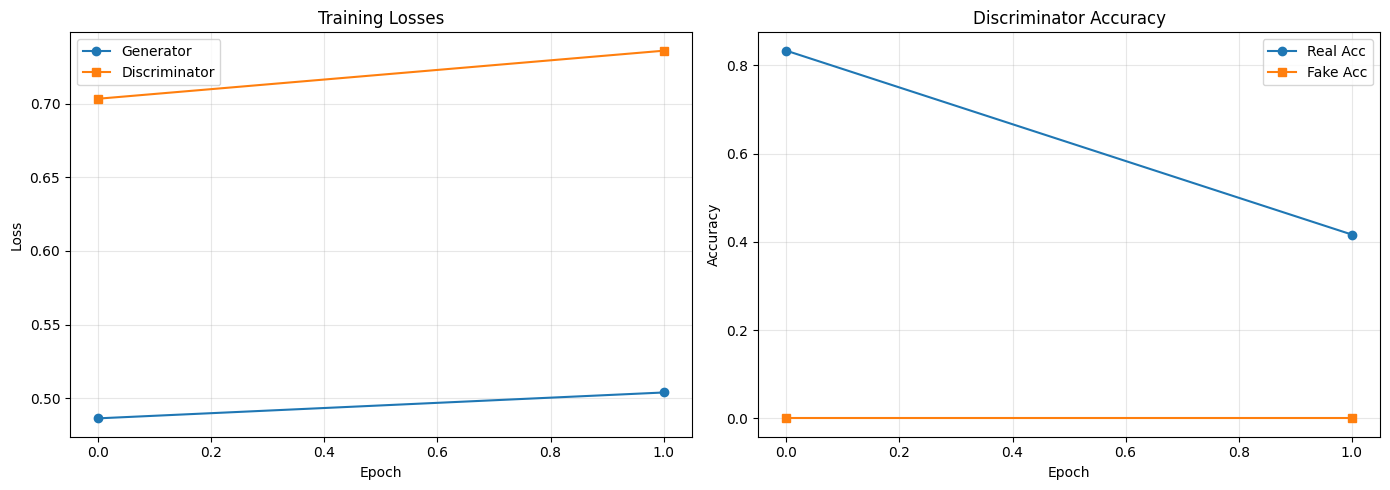

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot losses
if all_metrics['gen_loss']:
    axes[0].plot(all_metrics['gen_loss'], label='Generator', marker='o')
    axes[0].plot(all_metrics['disc_loss'], label='Discriminator', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Losses')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# Plot accuracy
if all_metrics['disc_real_acc']:
    axes[1].plot(all_metrics['disc_real_acc'], label='Real Acc', marker='o')
    axes[1].plot(all_metrics['disc_fake_acc'], label='Fake Acc', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Discriminator Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'training_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Models

In [17]:
# Save models
models_dir = output_dir / 'models'
models_dir.mkdir(exist_ok=True)

generator_path = models_dir / 'generator_final.pt'
discriminator_path = models_dir / 'discriminator_final.pt'

torch.save(generator.state_dict(), generator_path)
torch.save(discriminator.state_dict(), discriminator_path)

print(f"✅ Models saved:")
print(f"  Generator: {generator_path}")
print(f"  Discriminator: {discriminator_path}")

✅ Models saved:
  Generator: notebook_output/models/generator_final.pt
  Discriminator: notebook_output/models/discriminator_final.pt


In [18]:
# Save configuration
config_path = models_dir / 'config.json'

config_to_save = {
    'model_type': CONFIG['model_type'],
    'void_dim': CONFIG['void_dim'],
    'noise_dim': CONFIG['noise_dim'],
    'color_mode': CONFIG['color_mode'],
    'training': {
        'epochs': CONFIG['epochs'],
        'batch_size': CONFIG['batch_size'],
        'learning_rate': CONFIG['learning_rate'],
    },
    'training_time': training_time,
}

with open(config_path, 'w') as f:
    json.dump(config_to_save, f, indent=2)

print(f"✅ Config saved: {config_path}")

✅ Config saved: notebook_output/models/config.json


## 11. Generate Samples

In [19]:
# Generate samples
samples_dir = output_dir / 'generated_samples'
samples_dir.mkdir(exist_ok=True)

generator.eval()
generated_samples = []

print(f"🎨 Generating {CONFIG['num_eval_samples']} samples...\n")

with torch.no_grad():
    for i in range(CONFIG['num_eval_samples']):
        noise = torch.randn(1, CONFIG['noise_dim'], device=CONFIG['device'])
        sample = generator(noise)
        generated_samples.append(sample.cpu())
        
        # Save sample
        sample_path = samples_dir / f'sample_{i:03d}.pt'
        torch.save(sample.cpu(), sample_path)
        print(f"  Sample {i+1}: {sample.shape}")

print(f"\n✅ Generated {len(generated_samples)} samples")

🎨 Generating 3 samples...

  Sample 1: torch.Size([1, 1, 16, 16, 16])
  Sample 2: torch.Size([1, 1, 16, 16, 16])
  Sample 3: torch.Size([1, 1, 16, 16, 16])

✅ Generated 3 samples


## 12. Visualize Samples

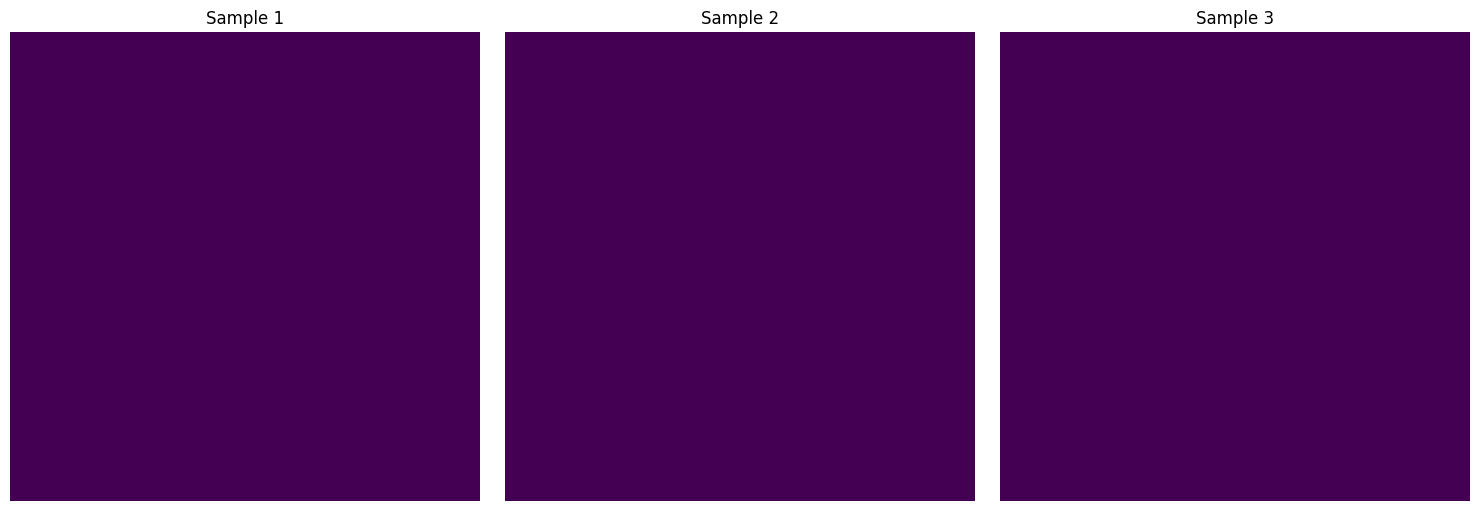

In [20]:
# Visualize samples
fig, axes = plt.subplots(1, CONFIG['num_eval_samples'], 
                        figsize=(5*CONFIG['num_eval_samples'], 5))

if CONFIG['num_eval_samples'] == 1:
    axes = [axes]

for i, sample in enumerate(generated_samples):
    sample_np = sample.squeeze().numpy()
    
    if sample_np.ndim == 4:
        sample_np = sample_np[0]
    
    mid_slice = sample_np.shape[0] // 2
    
    axes[i].imshow(sample_np[mid_slice], cmap='viridis')
    axes[i].set_title(f'Sample {i+1}')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(output_dir / 'generated_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Sample statistics
print("📊 Sample Statistics:\n")
for i, sample in enumerate(generated_samples):
    sample_np = sample.squeeze().numpy()
    if sample_np.ndim == 4:
        sample_np = sample_np[0]
    
    non_zero = (sample_np != 0).sum()
    total = sample_np.size
    sparsity = 1.0 - (non_zero / total)
    
    print(f"Sample {i+1}:")
    print(f"  Shape: {sample_np.shape}")
    print(f"  Range: [{sample_np.min():.3f}, {sample_np.max():.3f}]")
    print(f"  Sparsity: {sparsity:.3f}\n")

📊 Sample Statistics:

Sample 1:
  Shape: (16, 16, 16)
  Range: [1.000, 1.000]
  Sparsity: 0.000

Sample 2:
  Shape: (16, 16, 16)
  Range: [1.000, 1.000]
  Sparsity: 0.000

Sample 3:
  Shape: (16, 16, 16)
  Range: [1.000, 1.000]
  Sparsity: 0.000



## 13. Summary

In [22]:
print("=" * 60)
print("🎉 COMPLETE")
print("=" * 60)
print(f"Output: {CONFIG['output_dir']}")

🎉 COMPLETE
Output: ./notebook_output
